# Lab 06: Multiclass Logistic Regression

## Name: Abdul Hadi Saqib
## CMS: 467626
## Class: BESE-14A

### Task 1: Load and Preprocess the Glass Dataset

The Glass Identification dataset from UCI contains 214 samples of glass classified into multiple types based on oxide content. Each sample has 9 numeric features (refractive index, Na, Mg, Al, Si, K, Ca, Ba, Fe) and a class label indicating the glass type. The classes represent different glass origins such as building windows (float/non-float processed), vehicle windows, containers, tableware, and headlamps. This is a multi-class classification problem with 6 distinct classes present in the dataset.

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

basePath = os.path.dirname(os.path.abspath("__file__"))
csvPath = "/content/glass.csv"
df = pd.read_csv(csvPath)
print("Shape:", df.shape)
print("Columns:", list(df.columns))
df.head()

Shape: (214, 11)
Columns: ['Id', 'RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe', 'Type of glass']


,Id,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type of glass
0,1,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,2,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,3,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,4,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,5,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [13]:
X = df.drop(columns=["Id", "Type of glass"]).values.astype(np.float64)
y = df["Type of glass"].values.astype(int)

classes = np.unique(y)
numClasses = len(classes)
numFeatures = X.shape[1]

print(f"Number of classes: {numClasses}")
print(f"Classes: {classes}")
print(f"Number of features: {numFeatures}")
print(f"Total samples: {X.shape[0]}")
print("\nClass distribution:")
for c in classes:
    print(f"  Class {c}: {np.sum(y == c)} samples")

Number of classes: 6
Classes: [1 2 3 5 6 7]
Number of features: 9
Total samples: 214

Class distribution:
  Class 1: 70 samples
  Class 2: 76 samples
  Class 3: 17 samples
  Class 5: 13 samples
  Class 6: 9 samples
  Class 7: 29 samples


In [14]:
np.random.seed(42)
indices = np.random.permutation(len(X))
splitIdx = int(0.8 * len(X))

xTrain = X[indices[:splitIdx]]
xVal = X[indices[splitIdx:]]
yTrain = y[indices[:splitIdx]]
yVal = y[indices[splitIdx:]]

xMin = xTrain.min(axis=0)
xMax = xTrain.max(axis=0)
xRange = xMax - xMin
xRange[xRange == 0] = 1

xTrain = (xTrain - xMin) / xRange
xVal = (xVal - xMin) / xRange

print(f"Training set: {xTrain.shape[0]} samples")
print(f"Validation set: {xVal.shape[0]} samples")
print(f"Feature min after scaling: {xTrain.min(axis=0).round(4)}")
print(f"Feature max after scaling: {xTrain.max(axis=0).round(4)}")

Training set: 171 samples
Validation set: 43 samples
Feature min after scaling: [0. 0. 0. 0. 0. 0. 0. 0. 0.]
Feature max after scaling: [1. 1. 1. 1. 1. 1. 1. 1. 1.]


## Task 2: One-vs-Rest (OvR) Strategy

Train K independent binary logistic regression classifiers, one per class. Each classifier learns to distinguish its class from all others using sigmoid activation and binary cross-entropy loss.

In [15]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

def binaryCrossEntropy(yTrue, yPred):
    eps = 1e-15
    yPred = np.clip(yPred, eps, 1 - eps)
    return -np.mean(yTrue * np.log(yPred) + (1 - yTrue) * np.log(1 - yPred))

def trainBinaryClassifier(X, y, lr=0.1, epochs=2000):
    m, n = X.shape
    w = np.zeros(n)
    b = 0.0
    lossHistory = []

    for epoch in range(epochs):
        z = X @ w + b
        yPred = sigmoid(z)

        dw = (1 / m) * (X.T @ (yPred - y))
        db = (1 / m) * np.sum(yPred - y)

        w -= lr * dw
        b -= lr * db

        if epoch % 200 == 0:
            loss = binaryCrossEntropy(y, yPred)
            lossHistory.append(loss)

    return w, b, lossHistory

ovrWeights = {}
ovrBiases = {}
ovrLossHistories = {}

for cls in classes:
    yBinary = (yTrain == cls).astype(np.float64)
    w, b, lossHist = trainBinaryClassifier(xTrain, yBinary)
    ovrWeights[cls] = w
    ovrBiases[cls] = b
    ovrLossHistories[cls] = lossHist
    print(f"Class {cls}: final loss = {lossHist[-1]:.4f}")

Class 1: final loss = 0.4806
Class 2: final loss = 0.6001
Class 3: final loss = 0.2497
Class 5: final loss = 0.1504
Class 6: final loss = 0.1273
Class 7: final loss = 0.1043


Verifying probability outputs are between 0 and 1:
  Class 1: min=0.007234, max=0.725914
  Class 2: min=0.035121, max=0.555011
  Class 3: min=0.017694, max=0.152815
  Class 5: min=0.009533, max=0.732506
  Class 6: min=0.008347, max=0.422313
  Class 7: min=0.004484, max=0.967287


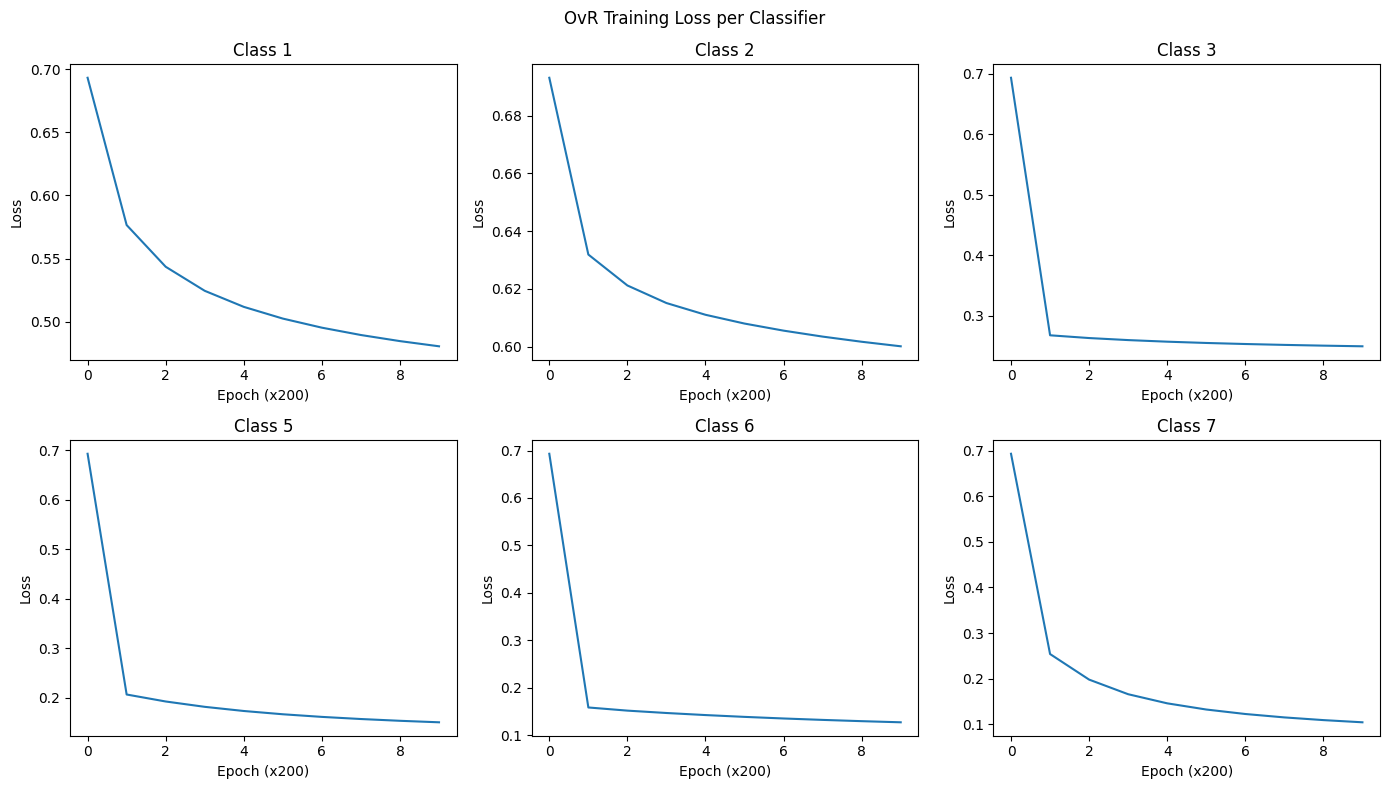

In [16]:
print("Verifying probability outputs are between 0 and 1:")
for cls in classes:
    probs = sigmoid(xTrain @ ovrWeights[cls] + ovrBiases[cls])
    print(f"  Class {cls}: min={probs.min():.6f}, max={probs.max():.6f}")

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
for i, cls in enumerate(classes):
    axes[i].plot(ovrLossHistories[cls])
    axes[i].set_title(f"Class {cls}")
    axes[i].set_xlabel("Epoch (x200)")
    axes[i].set_ylabel("Loss")
plt.suptitle("OvR Training Loss per Classifier")
plt.tight_layout()
plt.show()

## Task 3: OvR Multi-class Prediction and Evaluation

Combine all K binary classifiers. For each sample, pick the class with the highest probability. Compute accuracy, confusion matrix, precision, recall, F1-score per class, and macro F1.

In [17]:
def ovrPredict(X, weights, biases, classList):
    probMatrix = np.zeros((X.shape[0], len(classList)))
    for i, cls in enumerate(classList):
        probMatrix[:, i] = sigmoid(X @ weights[cls] + biases[cls])
    predictedIndices = np.argmax(probMatrix, axis=1)
    return np.array([classList[idx] for idx in predictedIndices])

yPredOvr = ovrPredict(xVal, ovrWeights, ovrBiases, classes)

ovrAccuracy = np.mean(yPredOvr == yVal)
print(f"OvR Overall Accuracy: {ovrAccuracy:.4f}")

OvR Overall Accuracy: 0.6047


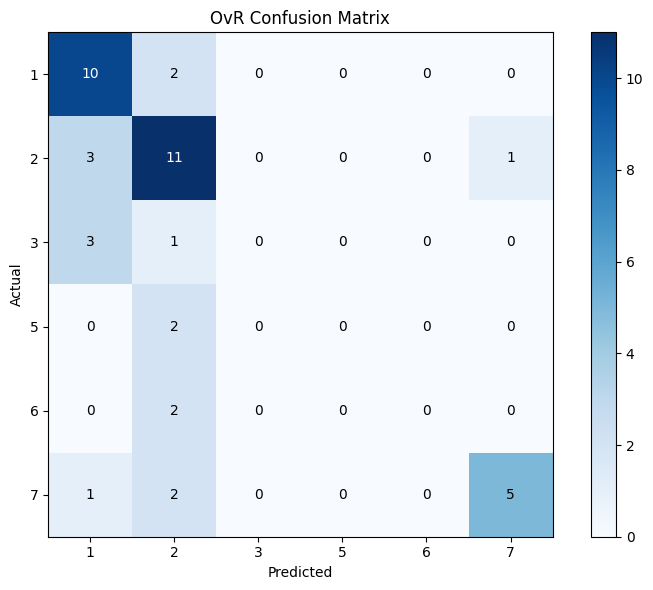


Class    Precision    Recall       F1-Score    
--------------------------------------------
1        0.5882       0.8333       0.6897      
2        0.5500       0.7333       0.6286      
3        0.0000       0.0000       0.0000      
5        0.0000       0.0000       0.0000      
6        0.0000       0.0000       0.0000      
7        0.8333       0.6250       0.7143      
--------------------------------------------
Macro                              0.3388      

Interpretation:
Classes with more training samples (1, 2, 7) tend to have higher recall and precision.
Minority classes (5, 6) may show lower recall due to limited training examples.
The confusion matrix reveals which classes are most often confused with each other.


In [18]:
def buildConfusionMatrix(yTrue, yPred, classList):
    k = len(classList)
    cm = np.zeros((k, k), dtype=int)
    classToIdx = {c: i for i, c in enumerate(classList)}
    for t, p in zip(yTrue, yPred):
        cm[classToIdx[t], classToIdx[p]] += 1
    return cm

def computeMetrics(cm, classList):
    k = len(classList)
    precision = np.zeros(k)
    recall = np.zeros(k)
    f1 = np.zeros(k)

    for i in range(k):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp

        precision[i] = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall[i] = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1[i] = 2 * precision[i] * recall[i] / (precision[i] + recall[i]) if (precision[i] + recall[i]) > 0 else 0.0

    macroF1 = np.mean(f1)
    return precision, recall, f1, macroF1

def plotConfusionMatrix(cm, classList, title):
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
    ax.set_title(title)
    plt.colorbar(im, ax=ax)
    tick = np.arange(len(classList))
    ax.set_xticks(tick)
    ax.set_xticklabels(classList)
    ax.set_yticks(tick)
    ax.set_yticklabels(classList)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

    thresh = cm.max() / 2.0
    for i in range(len(classList)):
        for j in range(len(classList)):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")
    plt.tight_layout()
    plt.show()

cmOvr = buildConfusionMatrix(yVal, yPredOvr, classes)
plotConfusionMatrix(cmOvr, classes, "OvR Confusion Matrix")

precOvr, recOvr, f1Ovr, macroF1Ovr = computeMetrics(cmOvr, classes)

print(f"\n{'Class':<8} {'Precision':<12} {'Recall':<12} {'F1-Score':<12}")
print("-" * 44)
for i, cls in enumerate(classes):
    print(f"{cls:<8} {precOvr[i]:<12.4f} {recOvr[i]:<12.4f} {f1Ovr[i]:<12.4f}")
print("-" * 44)
print(f"{'Macro':<8} {'':12} {'':12} {macroF1Ovr:<12.4f}")

print("\nInterpretation:")
print("Classes with more training samples (1, 2, 7) tend to have higher recall and precision.")
print("Minority classes (5, 6) may show lower recall due to limited training examples.")
print("The confusion matrix reveals which classes are most often confused with each other.")

## Task 4: Multinomial Logistic Regression (Softmax Regression)

Train a single model that computes probabilities for all K classes simultaneously using the softmax function and multinomial cross-entropy loss.

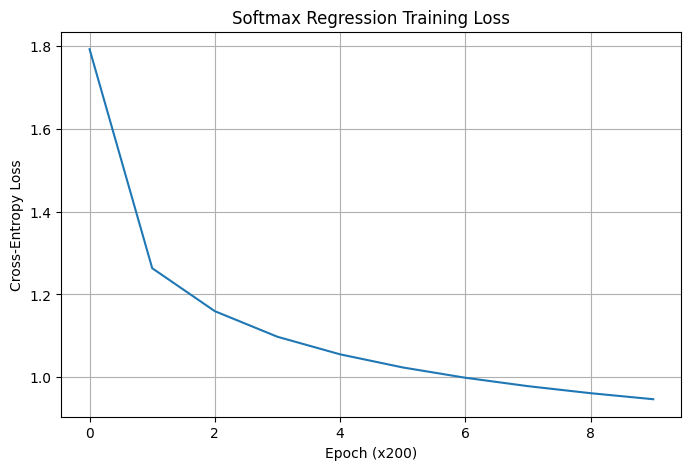

Final softmax loss: 0.9472
Probability sums (first 5 samples): [1. 1. 1. 1. 1.]


In [19]:
def softmax(z):
    zShifted = z - np.max(z, axis=1, keepdims=True)
    expZ = np.exp(zShifted)
    return expZ / np.sum(expZ, axis=1, keepdims=True)

def oneHotEncode(y, classList):
    classToIdx = {c: i for i, c in enumerate(classList)}
    encoded = np.zeros((len(y), len(classList)))
    for i, val in enumerate(y):
        encoded[i, classToIdx[val]] = 1.0
    return encoded

def crossEntropyLoss(yOneHot, probs):
    eps = 1e-15
    probs = np.clip(probs, eps, 1 - eps)
    return -np.mean(np.sum(yOneHot * np.log(probs), axis=1))

def trainSoftmax(X, y, classList, lr=0.1, epochs=2000):
    m, n = X.shape
    k = len(classList)
    W = np.zeros((n, k))
    B = np.zeros(k)
    yOneHot = oneHotEncode(y, classList)
    lossHistory = []

    for epoch in range(epochs):
        z = X @ W + B
        probs = softmax(z)

        dW = (1 / m) * (X.T @ (probs - yOneHot))
        dB = (1 / m) * np.sum(probs - yOneHot, axis=0)

        W -= lr * dW
        B -= lr * dB

        if epoch % 200 == 0:
            loss = crossEntropyLoss(yOneHot, probs)
            lossHistory.append(loss)

    return W, B, lossHistory

softmaxW, softmaxB, softmaxLossHistory = trainSoftmax(xTrain, yTrain, classes)

plt.figure(figsize=(8, 5))
plt.plot(softmaxLossHistory)
plt.title("Softmax Regression Training Loss")
plt.xlabel("Epoch (x200)")
plt.ylabel("Cross-Entropy Loss")
plt.grid(True)
plt.show()

print(f"Final softmax loss: {softmaxLossHistory[-1]:.4f}")

probsCheck = softmax(xTrain @ softmaxW + softmaxB)
print(f"Probability sums (first 5 samples): {probsCheck[:5].sum(axis=1)}")

Softmax Overall Accuracy: 0.5814


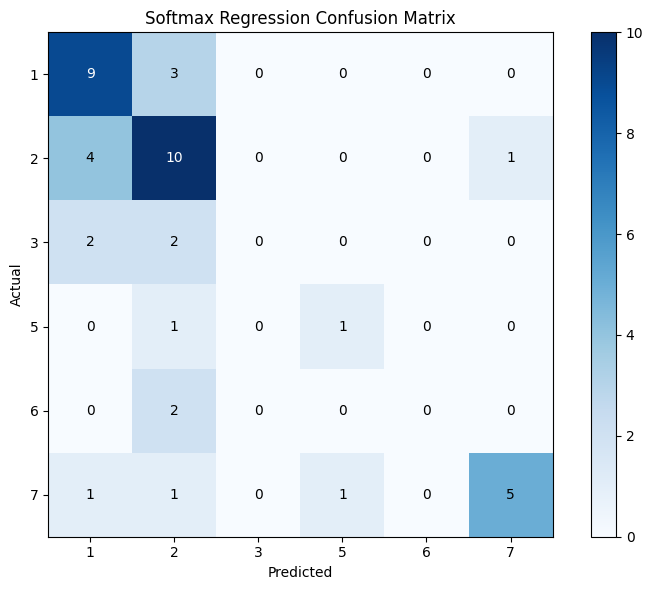


Class    Precision    Recall       F1-Score    
--------------------------------------------
1        0.5625       0.7500       0.6429      
2        0.5263       0.6667       0.5882      
3        0.0000       0.0000       0.0000      
5        0.5000       0.5000       0.5000      
6        0.0000       0.0000       0.0000      
7        0.8333       0.6250       0.7143      
--------------------------------------------
Macro                              0.4076      

Interpretation:
Softmax regression jointly models all classes, producing calibrated probabilities that sum to 1.
Majority classes (1, 2, 7) typically achieve higher F1-scores.
Minority classes may still be challenging but benefit from the shared parameter space.


In [20]:
def softmaxPredict(X, W, B, classList):
    z = X @ W + B
    probs = softmax(z)
    predictedIndices = np.argmax(probs, axis=1)
    return np.array([classList[idx] for idx in predictedIndices])

yPredSoftmax = softmaxPredict(xVal, softmaxW, softmaxB, classes)

softmaxAccuracy = np.mean(yPredSoftmax == yVal)
print(f"Softmax Overall Accuracy: {softmaxAccuracy:.4f}")

cmSoftmax = buildConfusionMatrix(yVal, yPredSoftmax, classes)
plotConfusionMatrix(cmSoftmax, classes, "Softmax Regression Confusion Matrix")

precSm, recSm, f1Sm, macroF1Sm = computeMetrics(cmSoftmax, classes)

print(f"\n{'Class':<8} {'Precision':<12} {'Recall':<12} {'F1-Score':<12}")
print("-" * 44)
for i, cls in enumerate(classes):
    print(f"{cls:<8} {precSm[i]:<12.4f} {recSm[i]:<12.4f} {f1Sm[i]:<12.4f}")
print("-" * 44)
print(f"{'Macro':<8} {'':12} {'':12} {macroF1Sm:<12.4f}")

print("\nInterpretation:")
print("Softmax regression jointly models all classes, producing calibrated probabilities that sum to 1.")
print("Majority classes (1, 2, 7) typically achieve higher F1-scores.")
print("Minority classes may still be challenging but benefit from the shared parameter space.")

## Task 5: Comparison of OvR vs Softmax Regression

Compare overall accuracy and macro F1-score between the two approaches and discuss computational trade-offs.

In [21]:
comparisonDf = pd.DataFrame({
    "Method": ["One-vs-Rest (OvR)", "Softmax Regression"],
    "Overall Accuracy": [f"{ovrAccuracy:.4f}", f"{softmaxAccuracy:.4f}"],
    "Macro F1-Score": [f"{macroF1Ovr:.4f}", f"{macroF1Sm:.4f}"]
})
print("=" * 55)
print("        Performance Comparison Table")
print("=" * 55)
print(comparisonDf.to_string(index=False))
print("=" * 55)

print("\nDiscussion:")
print(f"OvR trained {numClasses} separate binary classifiers, each with its own weight vector.")
print("This requires more computational effort as K independent models must be optimized.")
print("Softmax regression trains a single model with a shared weight matrix for all classes,")
print("making it more computationally efficient and producing calibrated probability outputs.")
print("Softmax probabilities sum to 1 across classes, unlike OvR where probabilities are independent.")

if softmaxAccuracy >= ovrAccuracy:
    print("\nSoftmax regression achieved equal or better overall performance while being")
    print("computationally more efficient with a single unified optimization.")
else:
    print("\nOvR achieved better accuracy, possibly because independent classifiers can")
    print("specialize better for each class boundary, though at higher computational cost.")

        Performance Comparison Table
            Method Overall Accuracy Macro F1-Score
 One-vs-Rest (OvR)           0.6047         0.3388
Softmax Regression           0.5814         0.4076

Discussion:
OvR trained 6 separate binary classifiers, each with its own weight vector.
This requires more computational effort as K independent models must be optimized.
Softmax regression trains a single model with a shared weight matrix for all classes,
making it more computationally efficient and producing calibrated probability outputs.
Softmax probabilities sum to 1 across classes, unlike OvR where probabilities are independent.

OvR achieved better accuracy, possibly because independent classifiers can
specialize better for each class boundary, though at higher computational cost.


-------------------------------------------------------